# Transfer learning, embeddings y explicabilidad — Enfermedades de mandioca

**Proyecto:** IC522 · Trabajo Final Integrador · **Alumno:** WLODECK, Fabricio Joaquín
**Datos:** 20 % del dataset filtrado (`datos\cambios 01 - no hojas\imagenes filtradas`, 26,304 imágenes)

Este notebook implementa:

1. **Ítems 1-2** — Transfer learning con dos backbones preentrenados (MobileNetV2 y EfficientNet-B7), cabeza propia, comparación por **macro-F1**. En timm 1.0.30, `efficientnet_b7` no publica pesos preentrenados, por lo que se usa `tf_efficientnet_b7` (misma arquitectura B7, pesos oficiales `ra_in1k`).
2. **Desbalance** — pesos de clase (`balanced`) en todos los entrenamientos.
3. **Splits** — subset 20 % → 80 % train+val (con val propio) / 20 % test; **test balanceado 60 por clase (300)**.
4. **Augmentación** — RandomCrop + VFlip + HFlip + RandomRotate(15°) vs. control sin augmentación (4 runs: E1-E4).
5. **Ítem 3** — Fine-tuning de MobileNetV2, con evaluación **antes y después** (E5).
6. **Ítem 4** — Clasificadores clásicos (RandomForest, SVM, XGBoost) y un MLP sobre embeddings del backbone.
7. **Ítem 6** — Explicabilidad con **LIME** sobre el modelo antes y después del fine-tuning + verificación de sesgos espurios.

## Fase 0 — Entorno, semillas y configuración

In [1]:
import os, sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from torchvision import transforms as T

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from IPython.display import display, Markdown

SMOKE = os.environ.get("SMOKE", "0") == "1"
TAG = "_smoke" if SMOKE else ""

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("torch:", torch.__version__, "| timm:", timm.__version__)
print("device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("modo SMOKE:", SMOKE)

d:\final_inteligencia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.14.0+cu126 | timm: 1.0.30
device: cuda - NVIDIA GeForce GTX 1660 SUPER
modo SMOKE: False


In [2]:
BASE = Path("D:/final_inteligencia")
DIR_IMG = BASE / "datos" / "cambios 01 - no hojas" / "imagenes filtradas"
DIR_LABELS = BASE / "datos" / "cambios 01 - no hojas" / "labels_filtrado.csv"
DIR_SPLIT = BASE / "datos" / "splits"
MANIFEST = DIR_SPLIT / "manifest_20pct.csv"
DIR_MODEL = BASE / "modelos"
DIR_REPORT = BASE / "reportes"
DIR_SPLIT.mkdir(parents=True, exist_ok=True)
DIR_MODEL.mkdir(parents=True, exist_ok=True)

SEED = 42
FRAC_SUBSET, FRAC_TESTPOOL, FRAC_VAL = 0.20, 0.20, 0.20
MAX_TEST_PC = 60
CLASS_NAMES = ["cbb", "cbsd", "cgm", "cmd", "healthy"]
NUM_CLASSES = 5
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

CONFIG = {
    "E1": dict(backbone="mobilenetv2_100", size=224, aug=False, epochs=20, batch=32, lr=1e-3, patience=4),
    "E2": dict(backbone="mobilenetv2_100", size=224, aug=True,  epochs=20, batch=32, lr=1e-3, patience=4),
    "E3": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=False, epochs=12, batch=4,  lr=1e-3, patience=4),
    "E4": dict(backbone="tf_efficientnet_b7.ra_in1k", size=600, aug=True,  epochs=12, batch=4,  lr=1e-3, patience=4),
}
FT_CFG = dict(epochs=6, lr=1e-4, patience=3, unfreeze=0.30)
LIME_SAMPLES = 500
LIME_POR_CLASE = 2

if SMOKE:
    for k in CONFIG:
        CONFIG[k].update(epochs=1, patience=1)
    CONFIG["E1"].update(batch=8)
    CONFIG["E2"].update(batch=8)
    CONFIG["E3"].update(batch=2)
    CONFIG["E4"].update(batch=2)
    FT_CFG.update(epochs=1, patience=1)
    LIME_SAMPLES, LIME_POR_CLASE = 60, 1

print(json.dumps({k: v for k, v in CONFIG.items()}, indent=1))
print("fine-tuning:", FT_CFG, "| LIME samples:", LIME_SAMPLES)

{
 "E1": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": false,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E2": {
  "backbone": "mobilenetv2_100",
  "size": 224,
  "aug": true,
  "epochs": 20,
  "batch": 32,
  "lr": 0.001,
  "patience": 4
 },
 "E3": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": false,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 },
 "E4": {
  "backbone": "tf_efficientnet_b7.ra_in1k",
  "size": 600,
  "aug": true,
  "epochs": 12,
  "batch": 4,
  "lr": 0.001,
  "patience": 4
 }
}
fine-tuning: {'epochs': 6, 'lr': 0.0001, 'patience': 3, 'unfreeze': 0.3} | LIME samples: 500


## Fase 1 — Datos: subset 20 %, train/val/test y test balanceado

Estratificación por **clase × source** (evita el sesgo de dominio 2019/2020, ver EDA §4.3), semilla 42:

1. subset = 20 % del dataset filtrado;
2. dentro del subset: 80 % train+val / 20 % test pool;
3. del train+val: 80 % train / 20 % val;
4. **test final balanceado**: 60 muestras por clase (limita CBB) muestreadas del test pool;
5. el resto del test pool queda **held-out** (no se entrena con él).

In [3]:
df_lab = pd.read_csv(DIR_LABELS)
df_lab["label_name"] = df_lab["label"].map(dict(enumerate(CLASS_NAMES)))
assert len(df_lab) == 26304 and df_lab["image_id"].is_unique

strata = df_lab["label"].astype(str) + "_" + df_lab["source"].astype(str)
subset_idx, _ = train_test_split(df_lab.index, train_size=FRAC_SUBSET, stratify=strata, random_state=SEED)

df_lab["split"] = "out_subset"
df_lab.loc[subset_idx, "split"] = "trainval"

sub = df_lab.loc[subset_idx]
strata_sub = sub["label"].astype(str) + "_" + sub["source"].astype(str)
trainval_idx, testpool_idx = train_test_split(sub.index, train_size=1 - FRAC_TESTPOOL,
                                              stratify=strata_sub, random_state=SEED)
df_lab.loc[testpool_idx, "split"] = "test_pool"

tv = df_lab.loc[trainval_idx]
strata_tv = tv["label"].astype(str) + "_" + tv["source"].astype(str)
train_idx, val_idx = train_test_split(tv.index, train_size=1 - FRAC_VAL,
                                      stratify=strata_tv, random_state=SEED)
df_lab.loc[train_idx, "split"] = "train"
df_lab.loc[val_idx, "split"] = "val"

pool = df_lab[df_lab["split"] == "test_pool"]
bal = pool.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(MAX_TEST_PC, len(g)), random_state=SEED), include_groups=False).index
df_lab.loc[df_lab.index.isin(bal), "split"] = "test"
df_lab.loc[df_lab["split"] == "test_pool", "split"] = "test_pool_rest"

In [4]:
print("== conteo por split ==")
print(df_lab["split"].value_counts().to_string())

ct = pd.crosstab(df_lab["label_name"], df_lab["split"])[["train", "val", "test", "test_pool_rest", "out_subset"]]
print("\n== clase x split ==")
display(ct)

print("== fuente x split ==")
display(pd.crosstab(df_lab["source"], df_lab["split"]))

assert len(df_lab) == 26304
s_tr = set(df_lab[df_lab.split == "train"]["image_id"])
s_va = set(df_lab[df_lab.split == "val"]["image_id"])
s_te = set(df_lab[df_lab.split == "test"]["image_id"])
assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
tc = df_lab[df_lab.split == "test"]["label"].value_counts().sort_index()
assert (tc == MAX_TEST_PC).all()
assert set(df_lab["split"]) == {"train", "val", "test", "test_pool_rest", "out_subset"}
print("OK: sin leakage | subset 20 % =", int((df_lab.split != "out_subset").sum()),
      "| test balanceado total =", int(tc.sum()))

manifest = df_lab[["image_id", "label", "label_name", "source", "split"]].copy()
if SMOKE:
    keep = set()
    for sp, n in [("train", 8), ("val", 4), ("test", 4)]:
        keep |= set(manifest[manifest.split == sp].groupby("label", group_keys=False).head(n).index)
    manifest.loc[~manifest.index.isin(keep), "split"] = "out_subset"
    print("SMOKE: train/val/test reducidos a 8/4/4 por clase")
    display(manifest[manifest.split != "out_subset"].groupby(["split", "label"]).size().unstack(0))

== conteo por split ==
split
out_subset        21044
train              3366
val                 842
test_pool_rest      752
test                300

== clase x split ==


split,train,val,test,test_pool_rest,out_subset
label_name,,,,,
cbb,191,48,60,0,1193
cbsd,440,110,60,78,2756
cgm,387,96,60,60,2414
cmd,1979,495,60,558,12370
healthy,369,93,60,56,2311


== fuente x split ==


split,out_subset,test,test_pool_rest,train,val
source,,,,,
2019,3952,61,137,632,158
2020,17092,239,615,2734,684


OK: sin leakage | subset 20 % = 5260 | test balanceado total = 300


manifest guardado en D:\final_inteligencia\datos\splits\manifest_20pct.csv


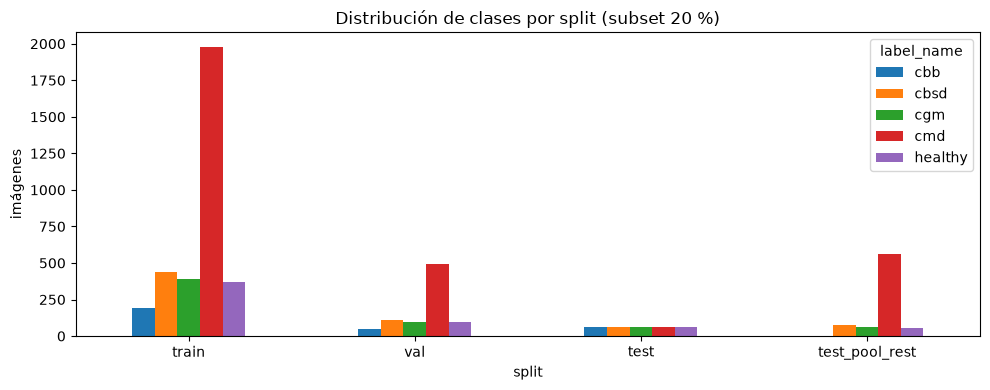

In [5]:
if not SMOKE:
    manifest.to_csv(MANIFEST, index=False)
    print("manifest guardado en", MANIFEST)
else:
    print("SMOKE: manifest NO se sobreescribe")

orden = ["train", "val", "test", "test_pool_rest", "out_subset"]
ct_plot = manifest[manifest.split != "out_subset"].groupby(["label_name", "split"]).size().unstack(0)[CLASS_NAMES]
ax = ct_plot.reindex(orden[:4]).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Distribución de clases por split (subset 20 %)")
ax.set_ylabel("imágenes"); ax.set_xlabel("split")
plt.tight_layout(); plt.show()

## Fase 2 — Infraestructura compartida

- **Transforms**: `Resize(256) + Crop(224)` (MobileNetV2) / `Resize(640) + Crop(600)` (EfficientNet-B7), sin deformar (EDA §4.4). Augmentación **solo** en train del brazo con aug: `RandomCrop`, `RandomVerticalFlip`, `RandomHorizontalFlip`, `RandomRotation(15°)`.
- **Pesos de clase** (`balanced`) calculados **solo sobre train**.
- **Cabeza**: GAP del backbone → Dropout(0.3) → Linear(5).
- **Selección**: mejor época por **macro-F1 de validación** + early stopping.

In [6]:
def build_transforms(size, aug):
    base = T.Resize(256 if size == 224 else 640, interpolation=T.InterpolationMode.BILINEAR)
    crop = T.RandomCrop(size) if aug else T.CenterCrop(size)
    ops = [base, crop]
    if aug:
        ops += [T.RandomVerticalFlip(0.5),
                T.RandomHorizontalFlip(0.5),
                T.RandomRotation(15)]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

class MandiocaDataset(Dataset):
    def __init__(self, manifest_df, split, transform):
        self.df = manifest_df[manifest_df["split"] == split].reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(DIR_IMG / r["image_id"]).convert("RGB")
        return self.transform(img), int(r["label"])

tr_labels = manifest.loc[manifest.split == "train", "label"].values
pesos = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=tr_labels)
CLASS_W = torch.tensor(pesos, dtype=torch.float32, device=DEVICE)
print("pesos de clase:", {CLASS_NAMES[i]: round(float(p), 3) for i, p in enumerate(pesos)})

tf_demo = build_transforms(224, True)
ds_demo = MandiocaDataset(manifest, "train", tf_demo)
x0, y0 = ds_demo[0]
print("batch ejemplo:", tuple(x0.shape), "| clase:", CLASS_NAMES[y0])

pesos de clase: {'cbb': 3.525, 'cbsd': 1.53, 'cgm': 1.74, 'cmd': 0.34, 'healthy': 1.824}
batch ejemplo: (3, 224, 224) | clase: cmd


In [7]:
class Clf(nn.Module):
    def __init__(self, backbone_name):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.head = nn.Sequential(nn.Dropout(0.3),
                                  nn.Linear(self.backbone.num_features, NUM_CLASSES))
    def train(self, mode=True):
        super().train(mode)
        if mode:
            self.backbone.eval()
        return self
    def forward(self, x):
        return self.head(self.backbone(x))
    def featurizador(self, x):
        return self.backbone(x)

@torch.no_grad()
def evaluar(model, dataset, batch_size=64):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    ys, ps = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        ps.append(model(x).argmax(1).cpu().numpy())
        ys.append(y.numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    per = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    return dict(f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
                f1_per_class=[float(v) for v in per],
                balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
                y_true=y_true.tolist(), y_pred=y_pred.tolist())

def eval_batch(cfg):
    if cfg["size"] == 224:
        return max(cfg["batch"], 32)
    return 8

In [8]:
def entrenar(exp_id, cfg):
    ckpt = DIR_MODEL / f"{exp_id}{TAG}.pth"
    res_path = DIR_MODEL / f"{exp_id}{TAG}_res.json"
    if ckpt.exists() and res_path.exists():
        print(f"[cache] {exp_id} ya entrenado")
        return json.loads(res_path.read_text(encoding="utf-8"))

    set_seed()
    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], cfg["aug"]))
    ds_va = MandiocaDataset(manifest, "val", build_transforms(cfg["size"], False))
    ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    model = Clf(cfg["backbone"]).to(DEVICE)
    for p in model.backbone.parameters():
        p.requires_grad = False
    model.eval()
    with torch.no_grad():
        f0 = model.backbone(torch.zeros(2, 3, cfg["size"], cfg["size"], device=DEVICE))
        sd0 = model.backbone.state_dict()
        n0 = sum(1 for v in sd0.values() if torch.is_tensor(v) and v.is_floating_point() and torch.isnan(v).any())
        print(f"{exp_id}: sanity feats_nan={torch.isnan(f0).any().item()} state_nan={n0}", flush=True)
    n_params = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg["lr"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    print(f"{exp_id}: train={len(ds_tr)} val={len(ds_va)} test={len(ds_te)} params={n_params:,} (entrenables={n_train:,})", flush=True)
    best_f1, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                if n_seen == 0 and ep == 1:
                    with torch.amp.autocast("cuda", enabled=use_amp):
                        f_dbg = model.backbone(x)
                        lg_dbg = model.head(f_dbg)
                    sd = model.backbone.state_dict()
                    nn_nan = sum(1 for v in sd.values() if torch.is_tensor(v) and v.is_floating_point() and torch.isnan(v).any())
                    neg_var = [k for k, v in sd.items() if k.endswith("running_var") and torch.is_tensor(v) and (v < 0).any().item()]
                    rb_nan = [k for k, v in sd.items() if "running" in k and torch.is_tensor(v) and torch.isnan(v).any()]
                    print(f"  [{exp_id}] DIAG x ok | feats nan={torch.isnan(f_dbg).any().item()} | "
                          f"backbone_state_nan={nn_nan} | running_nan={len(rb_nan)} {rb_nan[:3]} | "
                          f"neg_running_var={len(neg_var)} {neg_var[:3]} | "
                          f"loss={loss}", flush=True)
                print(f"  [{exp_id}] loss no finita en ep{ep}, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += float(loss) * len(y)
            n_seen += len(y)
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / n_seen, 4),
                            val_f1=round(ev["f1_macro"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  ep{ep}/{cfg['epochs']} loss={ep_loss / n_seen:.4f} valF1={ev['f1_macro']:.4f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["f1_macro"] > best_f1 + 1e-4:
            best_f1, wait = ev["f1_macro"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt)
    model.load_state_dict(best_state)
    va = evaluar(model, ds_va, batch_size=eval_batch(cfg))
    te = evaluar(model, ds_te, batch_size=eval_batch(cfg))
    res = dict(id=exp_id, metodo="transfer learning (cabeza)", backbone=cfg["backbone"],
               size=cfg["size"], aug=cfg["aug"], epochs_run=len(history),
               params=n_params, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               val=va, test=te, history=history)
    res_path.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"{exp_id} listo: valF1={va['f1_macro']:.4f} testF1={te['f1_macro']:.4f} ({res['tiempo_total_s']}s)")
    return res

RESULTADOS = {}

## Fase 3 — Experimentos de transfer learning (E1-E4)

| ID | Backbone | Input | Augmentación |
|---|---|---|---|
| E1 | MobileNetV2 | 224 | no |
| E2 | MobileNetV2 | 224 | **sí** (RandomCrop+VFlip+HFlip+Rotate) |
| E3 | EfficientNet-B7 | 600 | no |
| E4 | EfficientNet-B7 | 600 | **sí** |

In [9]:
RESULTADOS["E1"] = entrenar("E1", CONFIG["E1"])

E1: sanity feats_nan=False state_nan=0
E1: train=3366 val=842 test=300 params=2,230,277 (entrenables=6,405)


C:\Users\Fabricio\AppData\Local\Temp\ipykernel_5208\3648594462.py:59: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  ep_loss += float(loss) * len(y)


  ep1/20 loss=1.3126 valF1=0.5299 (195.7s)
  ep2/20 loss=1.0733 valF1=0.5709 (53.1s)
  ep3/20 loss=0.9890 valF1=0.5697 (50.2s)
  ep4/20 loss=0.9366 valF1=0.5889 (52.7s)
  ep5/20 loss=0.9069 valF1=0.5852 (50.2s)
  ep6/20 loss=0.8654 valF1=0.6021 (50.9s)
  ep7/20 loss=0.8531 valF1=0.5412 (53.0s)
  ep8/20 loss=0.8147 valF1=0.6039 (69.2s)
  ep9/20 loss=0.8086 valF1=0.5721 (51.7s)
  ep10/20 loss=0.7868 valF1=0.6002 (63.0s)
  ep11/20 loss=0.7897 valF1=0.6010 (57.8s)
  ep12/20 loss=0.7785 valF1=0.6152 (77.6s)
  ep13/20 loss=0.7580 valF1=0.5934 (60.5s)
  ep14/20 loss=0.7400 valF1=0.5890 (62.0s)
  ep15/20 loss=0.7397 valF1=0.5892 (56.7s)
  ep16/20 loss=0.7205 valF1=0.5966 (50.7s)
  early stopping
E1 listo: valF1=0.6152 testF1=0.5945 (1077.1s)


In [10]:
RESULTADOS["E2"] = entrenar("E2", CONFIG["E2"])

E2: sanity feats_nan=False state_nan=0
E2: train=3366 val=842 test=300 params=2,230,277 (entrenables=6,405)
  ep1/20 loss=1.3609 valF1=0.4763 (52.2s)
  ep2/20 loss=1.1718 valF1=0.5031 (51.7s)
  ep3/20 loss=1.1091 valF1=0.5326 (62.2s)
  ep4/20 loss=1.0648 valF1=0.5404 (60.9s)
  ep5/20 loss=1.0518 valF1=0.5123 (57.8s)
  ep6/20 loss=0.9986 valF1=0.5244 (63.1s)
  ep7/20 loss=1.0132 valF1=0.4799 (57.0s)
  ep8/20 loss=0.9904 valF1=0.5654 (53.4s)
  ep9/20 loss=0.9720 valF1=0.5123 (56.2s)
  ep10/20 loss=0.9655 valF1=0.5539 (57.8s)
  ep11/20 loss=0.9477 valF1=0.5638 (58.4s)
  ep12/20 loss=0.9580 valF1=0.5854 (62.2s)
  ep13/20 loss=0.9612 valF1=0.5503 (57.5s)
  ep14/20 loss=0.9354 valF1=0.5572 (58.6s)
  ep15/20 loss=0.9469 valF1=0.5468 (53.2s)
  ep16/20 loss=0.9285 valF1=0.5522 (52.9s)
  early stopping
E2 listo: valF1=0.5854 testF1=0.5761 (931.8s)


In [11]:
RESULTADOS["E3"] = entrenar("E3", CONFIG["E3"])

E3: sanity feats_nan=False state_nan=0
E3: train=3366 val=842 test=300 params=63,799,765 (entrenables=12,805)
  ep1/12 loss=1.1082 valF1=0.5959 (651.5s)
  ep2/12 loss=0.9015 valF1=0.6287 (622.5s)
  ep3/12 loss=0.8274 valF1=0.6551 (625.6s)
  ep4/12 loss=0.7998 valF1=0.6462 (621.1s)
  ep5/12 loss=0.7719 valF1=0.6198 (617.7s)
  ep6/12 loss=0.7261 valF1=0.5987 (626.6s)
  ep7/12 loss=0.7080 valF1=0.6106 (623.6s)
  early stopping
E3 listo: valF1=0.6551 testF1=0.6267 (4480.2s)


In [12]:
RESULTADOS["E4"] = entrenar("E4", CONFIG["E4"])

E4: sanity feats_nan=False state_nan=0
E4: train=3366 val=842 test=300 params=63,799,765 (entrenables=12,805)
  ep1/12 loss=1.1167 valF1=0.5799 (639.2s)
  ep2/12 loss=0.9284 valF1=0.6032 (689.5s)
  ep3/12 loss=0.8698 valF1=0.6416 (659.9s)
  ep4/12 loss=0.8468 valF1=0.6449 (623.5s)
  ep5/12 loss=0.8320 valF1=0.6209 (624.8s)
  ep6/12 loss=0.7976 valF1=0.6285 (629.3s)
  ep7/12 loss=0.7882 valF1=0.5804 (647.6s)
  ep8/12 loss=0.7657 valF1=0.6455 (663.0s)
  ep9/12 loss=0.7469 valF1=0.6421 (703.3s)
  ep10/12 loss=0.7618 valF1=0.5393 (670.0s)
  ep11/12 loss=0.7480 valF1=0.6073 (620.2s)
  ep12/12 loss=0.7579 valF1=0.6127 (631.0s)
  early stopping
E4 listo: valF1=0.6455 testF1=0.6482 (7892.8s)


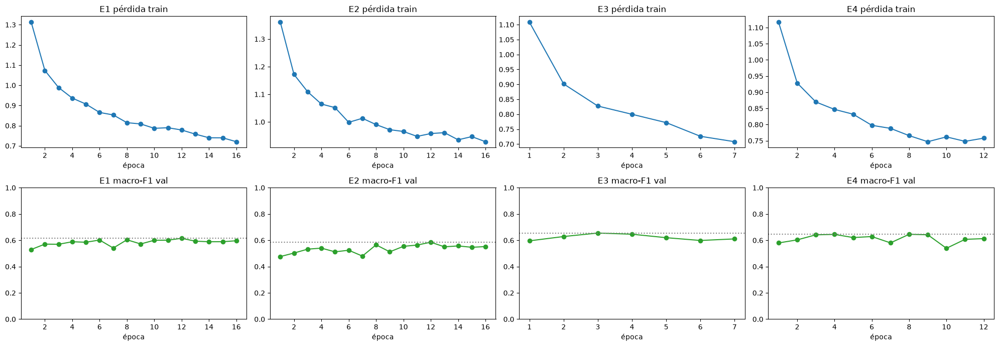

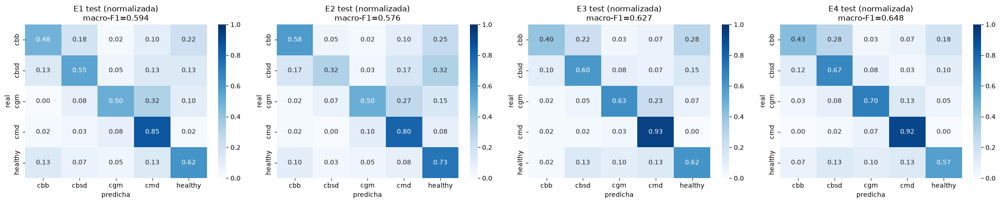

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    h = pd.DataFrame(RESULTADOS[eid]["history"])
    axes[0, j].plot(h["epoch"], h["train_loss"], marker="o")
    axes[0, j].set_title(f"{eid} pérdida train"); axes[0, j].set_xlabel("época")
    axes[1, j].plot(h["epoch"], h["val_f1"], marker="o", color="tab:green")
    axes[1, j].axhline(RESULTADOS[eid]["val"]["f1_macro"], ls=":", color="gray")
    axes[1, j].set_title(f"{eid} macro-F1 val"); axes[1, j].set_xlabel("época")
    axes[1, j].set_ylim(0, 1)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
for j, eid in enumerate(["E1", "E2", "E3", "E4"]):
    te = RESULTADOS[eid]["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[j],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[j].set_title(f"{eid} test (normalizada)\nmacro-F1={te['f1_macro']:.3f}")
    axes[j].set_xlabel("predicha"); axes[j].set_ylabel("real")
plt.tight_layout(); plt.show()

In [14]:
filas = []
for eid in ["E1", "E2", "E3", "E4"]:
    r = RESULTADOS[eid]
    filas.append(dict(ID=eid, Metodo="TL cabeza", Backbone=r["backbone"], Input=r["size"],
                      Aug="si" if r["aug"] else "no", Epocas=r["epochs_run"],
                      F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                      BalAcc=r["test"]["balanced_acc"], Params=r["params"],
                      s_epoc=r["tiempo_ep_s"]))
tabla_e = pd.DataFrame(filas)
display(tabla_e.round(4))

,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,F1_test,BalAcc,Params,s_epoc
0,E1,TL cabeza,mobilenetv2_100,224,no,16,0.6152,0.5945,0.6000,2230277,65.9
1,E2,TL cabeza,mobilenetv2_100,224,si,16,0.5854,0.5761,0.5867,2230277,57.2
2,E3,TL cabeza,tf_efficientnet_b7.ra_in1k,600,no,7,0.6551,0.6267,0.6367,63799765,626.9
3,E4,TL cabeza,tf_efficientnet_b7.ra_in1k,600,si,12,0.6455,0.6482,0.6567,63799765,650.1


## Fase 4 — Fine-tuning de MobileNetV2 (E5): evaluación antes / después

- Se elige el mejor de E1/E2 por macro-F1 de validación → **checkpoint A = "antes"**.
- Se descongelan los **últimos ~30 % de parámetros** del backbone (head siempre entrenable), Adam `lr=1e-4`, ≤6 épocas, early stopping.
- **Checkpoint B = "después"**; se evalúa A y B con la **misma función** sobre val y test balanceado.

In [15]:
mv2_ids = ["E1", "E2"]
mejor_mv2 = max(mv2_ids, key=lambda i: RESULTADOS[i]["val"]["f1_macro"])
print("mejor config MobileNetV2:", mejor_mv2,
      "| val F1 =", round(RESULTADOS[mejor_mv2]["val"]["f1_macro"], 4))

def fine_tuning(exp_antes):
    ckpt_b = DIR_MODEL / f"E5{TAG}.pth"
    res_b = DIR_MODEL / f"E5{TAG}_res.json"
    if ckpt_b.exists() and res_b.exists():
        print("[cache] E5 ya entrenado")
        return json.loads(res_b.read_text(encoding="utf-8"))

    set_seed()
    cfg = CONFIG[exp_antes]
    model = Clf(cfg["backbone"]).to(DEVICE)
    model.load_state_dict(torch.load(DIR_MODEL / f"{exp_antes}{TAG}.pth", map_location=DEVICE))

    for p in model.parameters():
        p.requires_grad = False
    named = dict(model.backbone.named_parameters())
    nom = list(named.keys())
    k = int(len(nom) * FT_CFG["unfreeze"])
    for n in nom[len(nom) - k:]:
        named[n].requires_grad = True
    n_ent = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_tot = sum(p.numel() for p in model.parameters())
    print(f"descongelados {k}/{len(nom)} tensores backbone -> {n_ent:,} params entrenables de {n_tot:,}")

    ds_tr = MandiocaDataset(manifest, "train", build_transforms(cfg["size"], cfg["aug"]))
    ds_va = MandiocaDataset(manifest, "val", build_transforms(cfg["size"], False))
    ds_te = MandiocaDataset(manifest, "test", build_transforms(cfg["size"], False))
    dl_tr = DataLoader(ds_tr, batch_size=cfg["batch"], shuffle=True, num_workers=0,
                       generator=torch.Generator().manual_seed(SEED))

    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=FT_CFG["lr"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W)
    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_f1, best_state, wait, history, t0 = -1.0, None, 0, [], time.time()
    for ep in range(1, FT_CFG["epochs"] + 1):
        model.train()
        ep_loss, n_seen, ep_t = 0.0, 0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                loss = crit(model(x), y)
            if not torch.isfinite(loss):
                print("  [E5] loss no finita, batch descartado", flush=True)
                continue
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            ep_loss += float(loss) * len(y)
            n_seen += len(y)
        ev = evaluar(model, ds_va, batch_size=eval_batch(cfg))
        history.append(dict(epoch=ep, train_loss=round(ep_loss / n_seen, 4),
                            val_f1=round(ev["f1_macro"], 4),
                            epoch_time_s=round(time.time() - ep_t, 1)))
        print(f"  FT ep{ep}/{FT_CFG['epochs']} loss={ep_loss / n_seen:.4f} valF1={ev['f1_macro']:.4f} ({history[-1]['epoch_time_s']}s)", flush=True)
        if ev["f1_macro"] > best_f1 + 1e-4:
            best_f1, wait = ev["f1_macro"], 0
            best_state = {kk: v.detach().cpu().clone() for kk, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= FT_CFG["patience"]:
                print("  early stopping")
                break

    torch.save(best_state, ckpt_b)
    model.load_state_dict(best_state)
    va = evaluar(model, ds_va, batch_size=eval_batch(cfg))
    te = evaluar(model, ds_te, batch_size=eval_batch(cfg))
    res = dict(id="E5", metodo="fine-tuning MV2 (30 % backbone)", backbone=cfg["backbone"],
               size=cfg["size"], aug=cfg["aug"], epochs_run=len(history),
               params=n_ent, tiempo_total_s=round(time.time() - t0, 1),
               tiempo_ep_s=round(float(np.mean([h["epoch_time_s"] for h in history])), 1),
               antes=exp_antes, val=va, test=te, history=history)
    res_b.write_text(json.dumps(res, indent=1), encoding="utf-8")
    print(f"E5 listo: valF1={va['f1_macro']:.4f} testF1={te['f1_macro']:.4f}")
    return res

RESULTADOS["E5"] = fine_tuning(mejor_mv2)
print("antes:", RESULTADOS[mejor_mv2]["val"]["f1_macro"], "| despues:", RESULTADOS["E5"]["val"]["f1_macro"])

mejor config MobileNetV2: E1 | val F1 = 0.6152
descongelados 46/156 tensores backbone -> 1,743,744 params entrenables de 2,230,277
  FT ep1/6 loss=0.8223 valF1=0.5911 (50.3s)
  FT ep2/6 loss=0.6658 valF1=0.5863 (44.8s)
  FT ep3/6 loss=0.5484 valF1=0.6322 (44.6s)
  FT ep4/6 loss=0.4109 valF1=0.6213 (44.3s)
  FT ep5/6 loss=0.3078 valF1=0.6610 (43.9s)
  FT ep6/6 loss=0.2189 valF1=0.6875 (44.0s)
E5 listo: valF1=0.6875 testF1=0.6189
antes: 0.615210325811482 | despues: 0.6875158585483238


,Estado,Back,F1_val,F1_test,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy,BalAcc
0,E1 (antes FT),cabeza congelada,0.6152,0.5945,0.5472,0.5739,0.5882,0.6711,0.5920,0.6000
1,E5 (despues FT),fine-tuning 30 %,0.6875,0.6189,0.6038,0.6557,0.5625,0.6962,0.5763,0.6267


delta test macro-F1: 0.0244


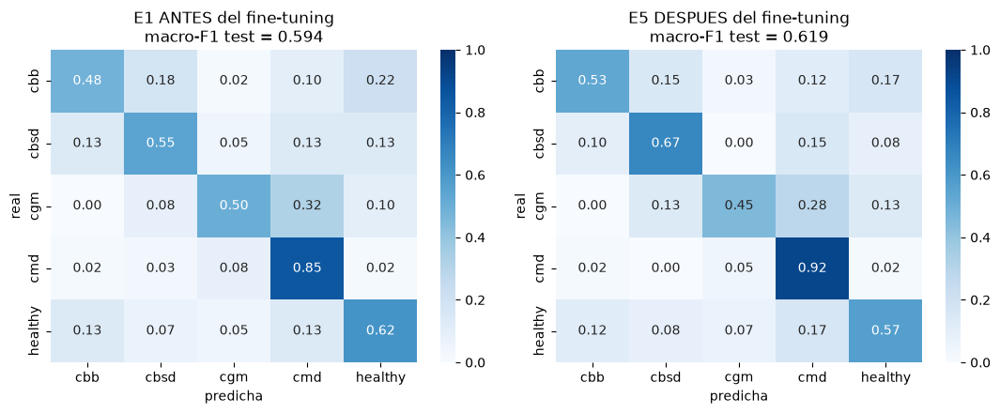

In [16]:
res_antes, res_des = RESULTADOS[mejor_mv2], RESULTADOS["E5"]
filas = []
for etiqueta, estado, r in [(f"{mejor_mv2} (antes FT)", "cabeza congelada", res_antes),
                            ("E5 (despues FT)", "fine-tuning 30 %", res_des)]:
    filas.append(dict(Estado=etiqueta, Back=estado, F1_val=r["val"]["f1_macro"],
                      F1_test=r["test"]["f1_macro"],
                      **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)},
                      BalAcc=r["test"]["balanced_acc"]))
tabla_ab = pd.DataFrame(filas)
display(tabla_ab.round(4))
print("delta test macro-F1:", round(res_des["test"]["f1_macro"] - res_antes["test"]["f1_macro"], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (titulo, r) in zip(axes, [(f"{mejor_mv2} ANTES del fine-tuning", res_antes),
                                  ("E5 DESPUES del fine-tuning", res_des)]):
    te = r["test"]
    cm = confusion_matrix(te["y_true"], te["y_pred"], labels=np.arange(NUM_CLASSES), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{titulo}\nmacro-F1 test = {te['f1_macro']:.3f}")
    ax.set_xlabel("predicha"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()

## Fase 5 — Ítem 4: embeddings + clasificadores clásicos (y una red sobre embeddings)

- Features = salida del **GAP del backbone ImageNet congelado** (sin head), mismas transformaciones de evaluación; se cachean en `.npz`.
- Clasificadores: **RandomForest** (`class_weight=balanced_subsample`), **SVM RBF** (grid chico C/γ sobre val, `class_weight=balanced`), **XGBoost** (`sample_weight` balanceado) y un **MLP end-to-end** con pesos de clase.
- Se comparan contra las redes end-to-end E1-E5 con la misma métrica y el mismo test balanceado.

In [17]:
@torch.no_grad()
def extraer_embeddings(backbone_name, size, split):
    cache = DIR_MODEL / f"emb_{backbone_name}_{split}{TAG}.npz"
    if cache.exists():
        d = np.load(cache)
        print(f"[cache] emb {backbone_name} {split}: {d['X'].shape}")
        return d["X"], d["y"]
    model = Clf(backbone_name).to(DEVICE)
    model.eval()
    ds = MandiocaDataset(manifest, split, build_transforms(size, False))
    dl = DataLoader(ds, batch_size=8 if size == 600 else 64, shuffle=False, num_workers=0)
    feats, labs = [], []
    for x, y in dl:
        f = model.featurizador(x.to(DEVICE)).float().cpu().numpy()
        feats.append(f); labs.append(y.numpy())
    X = np.concatenate(feats).astype(np.float32)
    y = np.concatenate(labs)
    np.savez_compressed(cache, X=X, y=y)
    print(f"emb {backbone_name} {split}: {X.shape}")
    return X, y

EMB = {}
for bb_name, bb_size in [("mobilenetv2_100", 224), ("tf_efficientnet_b7.ra_in1k", 600)]:
    EMB[bb_name] = {}
    for sp in ["train", "val", "test"]:
        X, y = extraer_embeddings(bb_name, bb_size, sp)
        EMB[bb_name][sp] = (X, y)
    assert EMB[bb_name]["train"][1].shape[0] == int((manifest.split == "train").sum())

emb mobilenetv2_100 train: (3366, 1280)
emb mobilenetv2_100 val: (842, 1280)
emb mobilenetv2_100 test: (300, 1280)
emb tf_efficientnet_b7.ra_in1k train: (3366, 2560)
emb tf_efficientnet_b7.ra_in1k val: (842, 2560)
emb tf_efficientnet_b7.ra_in1k test: (300, 2560)


In [18]:
def bb_key(name):
    return "mobilenetv2" if name.startswith("mobilenet") else "efficientnet"

def metricas_sklearn(y_true, y_pred):
    per = f1_score(y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0)
    return dict(f1_macro=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
                f1_per_class=[float(v) for v in per],
                balanced_acc=float(balanced_accuracy_score(y_true, y_pred)),
                y_true=np.asarray(y_true).tolist(), y_pred=np.asarray(y_pred).tolist())

def registrar_ml(exp_id, metodo, backbone, extra, val_m, test_m, params, t_s):
    res = dict(id=exp_id, metodo=metodo, backbone=backbone, size=None, aug=None,
               epochs_run=None, params=params, tiempo_total_s=round(t_s, 1),
               tiempo_ep_s=None, extra=extra, val=val_m, test=test_m)
    (DIR_MODEL / f"{exp_id}{TAG}_res.json").write_text(json.dumps(res, indent=1), encoding="utf-8")
    return res

def pesos_balanceados(y):
    n = len(y); k = NUM_CLASSES
    counts = np.bincount(np.asarray(y), minlength=k)
    return n / (k * counts[y])

In [19]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    t0 = time.time()
    clf = RandomForestClassifier(n_estimators=500, class_weight="balanced_subsample",
                                 random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, ytr)
    res = registrar_ml(f"E6_{bb_key(bb_name)}", "RandomForest", bb_name, "n=500",
                       metricas_sklearn(yv, clf.predict(Xv)),
                       metricas_sklearn(yt, clf.predict(Xt)),
                       500, time.time() - t0)
    print(bb_name, "RF test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 RF test F1 = 0.2942
tf_efficientnet_b7.ra_in1k RF test F1 = 0.3342


In [20]:
mejores = {}
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    mejor = None
    t0 = time.time()
    for C in [1, 10]:
        for gamma in ["scale", 1e-3]:
            clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=SEED)
            clf.fit(Xtr_s, ytr)
            f1v = f1_score(yv, clf.predict(Xv_s), average="macro", zero_division=0)
            print(f"  {bb_name} SVM C={C} gamma={gamma} valF1={f1v:.4f}")
            if mejor is None or f1v > mejor[0]:
                mejor = (f1v, C, gamma, clf)
    _, C_best, gamma_best, clf = mejor
    res = registrar_ml(f"E7_{bb_key(bb_name)}", "SVM RBF", bb_name, f"C={C_best}, gamma={gamma_best}",
                       metricas_sklearn(yv, clf.predict(Xv_s)),
                       metricas_sklearn(yt, clf.predict(Xt_s)),
                       len(clf.support_), time.time() - t0)
    print(bb_name, "SVM test F1 =", round(res["test"]["f1_macro"], 4))

  mobilenetv2_100 SVM C=1 gamma=scale valF1=0.6204
  mobilenetv2_100 SVM C=1 gamma=0.001 valF1=0.6096
  mobilenetv2_100 SVM C=10 gamma=scale valF1=0.6063
  mobilenetv2_100 SVM C=10 gamma=0.001 valF1=0.5842
mobilenetv2_100 SVM test F1 = 0.5623
  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=scale valF1=0.6194
  tf_efficientnet_b7.ra_in1k SVM C=1 gamma=0.001 valF1=0.5667
  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=scale valF1=0.6370
  tf_efficientnet_b7.ra_in1k SVM C=10 gamma=0.001 valF1=0.5449
tf_efficientnet_b7.ra_in1k SVM test F1 = 0.5837


In [21]:
for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    t0 = time.time()
    import xgboost as xgb
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                            objective="multi:softprob", num_class=NUM_CLASSES,
                            eval_metric="mlogloss", tree_method="hist",
                            random_state=SEED, n_jobs=-1, reg_lambda=1.0)
    clf.fit(Xtr, ytr, sample_weight=pesos_balanceados(ytr),
            eval_set=[(Xv, yv)], verbose=False)
    res = registrar_ml(f"E8_{bb_key(bb_name)}", "XGBoost", bb_name, "n=300, d=6, lr=0.1",
                       metricas_sklearn(yv, clf.predict(Xv)),
                       metricas_sklearn(yt, clf.predict(Xt)),
                       300, time.time() - t0)
    print(bb_name, "XGB test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 XGB test F1 = 0.5295
tf_efficientnet_b7.ra_in1k XGB test F1 = 0.5669


In [22]:
def entrenar_mlp(Xtr, ytr, Xv, yv, Xt, yt, epochs=150, batch=256):
    set_seed()
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xv_s, Xt_s = sc.transform(Xtr), sc.transform(Xv), sc.transform(Xt)
    F = Xtr_s.shape[1]
    model = nn.Sequential(nn.Linear(F, 256), nn.ReLU(), nn.Dropout(0.3),
                          nn.Linear(256, NUM_CLASSES)).to(DEVICE)
    counts = np.bincount(np.asarray(ytr), minlength=NUM_CLASSES).astype(np.float64)
    w = torch.tensor(len(ytr) / (NUM_CLASSES * counts), dtype=torch.float32, device=DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xv_t = torch.tensor(Xv_s, dtype=torch.float32, device=DEVICE)
    yv_t = torch.tensor(yv, dtype=torch.long, device=DEVICE)
    n = len(Xtr_t)
    best_f1, best_state, wait, t0 = -1.0, None, 0, time.time()
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i + batch]
            xb, yb = Xtr_t[idx].to(DEVICE), ytr_t[idx].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            f1v = f1_score(yv_t.cpu().numpy(), model(Xv_t).argmax(1).cpu().numpy(),
                           average="macro", zero_division=0)
        if f1v > best_f1 + 1e-4:
            best_f1, wait = f1v, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= 15:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_v = model(Xv_t).argmax(1).cpu().numpy()
        pred_t = model(torch.tensor(Xt_s, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
    return pred_v, pred_t, model, time.time() - t0

for bb_name in ["mobilenetv2_100", "tf_efficientnet_b7.ra_in1k"]:
    Xtr, ytr = EMB[bb_name]["train"]
    Xv, yv = EMB[bb_name]["val"]
    Xt, yt = EMB[bb_name]["test"]
    pred_v, pred_t, model_mlp, t_s = entrenar_mlp(Xtr, ytr, Xv, yv, Xt, yt,
                                                  epochs=2 if SMOKE else 150)
    n_par = sum(p.numel() for p in model_mlp.parameters())
    res = registrar_ml(f"E9_{bb_key(bb_name)}", "MLP (red sobre embeddings)", bb_name,
                       "256 ocultas", metricas_sklearn(yv, pred_v),
                       metricas_sklearn(yt, pred_t), n_par, t_s)
    print(bb_name, "MLP test F1 =", round(res["test"]["f1_macro"], 4))

mobilenetv2_100 MLP test F1 = 0.5629
tf_efficientnet_b7.ra_in1k MLP test F1 = 0.6148


## Fase 6 — Ítem 6: explicabilidad con LIME (antes y después del fine-tuning) + sesgos espurios

- **Mismas imágenes** del test balanceado explicadas con el **checkpoint A** (mejor MV2, cabeza) y el **checkpoint B** (E5, fine-tuned).
- Verificación de sesgo: macro-F1 del test **por fuente (2019 vs 2020)** y revisión de qué regiones resalta LIME (hoja vs fondo/marco).

In [23]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

modelo_A = Clf(CONFIG[mejor_mv2]["backbone"]).to(DEVICE)
modelo_A.load_state_dict(torch.load(DIR_MODEL / f"{mejor_mv2}{TAG}.pth", map_location=DEVICE))
modelo_A.eval()
modelo_B = Clf(CONFIG[mejor_mv2]["backbone"]).to(DEVICE)
modelo_B.load_state_dict(torch.load(DIR_MODEL / f"E5{TAG}.pth", map_location=DEVICE))
modelo_B.eval()

tf_vis = T.Compose([T.Resize(256), T.CenterCrop(224)])

df_test = manifest[manifest.split == "test"].reset_index(drop=True)
muestra = df_test.groupby("label", group_keys=False).apply(
    lambda g: g.sample(n=min(LIME_POR_CLASE, len(g)), random_state=SEED),
    include_groups=False).reset_index(drop=True)
print("imágenes a explicar:", len(muestra))
display(muestra[["image_id", "label_name", "source"]])

def hacer_fn(modelo):
    def fn(imgs):
        arr = np.asarray(imgs, dtype=np.float32)
        if arr.ndim == 3:
            arr = arr[None]
        if arr.max() > 1.5:
            arr = arr / 255.0
        t = torch.from_numpy(arr).permute(0, 3, 1, 2).to(DEVICE)
        mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
        std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
        with torch.no_grad():
            p = torch.softmax(modelo((t - mean) / std), dim=1)
        return p.cpu().numpy()
    return fn

fn_A, fn_B = hacer_fn(modelo_A), hacer_fn(modelo_B)
explainer = lime_image.LimeImageExplainer()

imágenes a explicar: 10


,image_id,label_name,source
0,1089759212.jpg,cbb,2020
1,1501728003.jpg,cbb,2020
2,1052028548.jpg,cbsd,2020
3,1479311027.jpg,cbsd,2020
4,100533489.jpg,cgm,2020
5,1489666486.jpg,cgm,2020
6,1009495847.jpg,cmd,2020
7,1425189269.jpg,cmd,2020
8,1045099368.jpg,healthy,2020
9,1445324291.jpg,healthy,2020


100%|██████████| 500/500 [00:02<00:00, 234.99it/s]


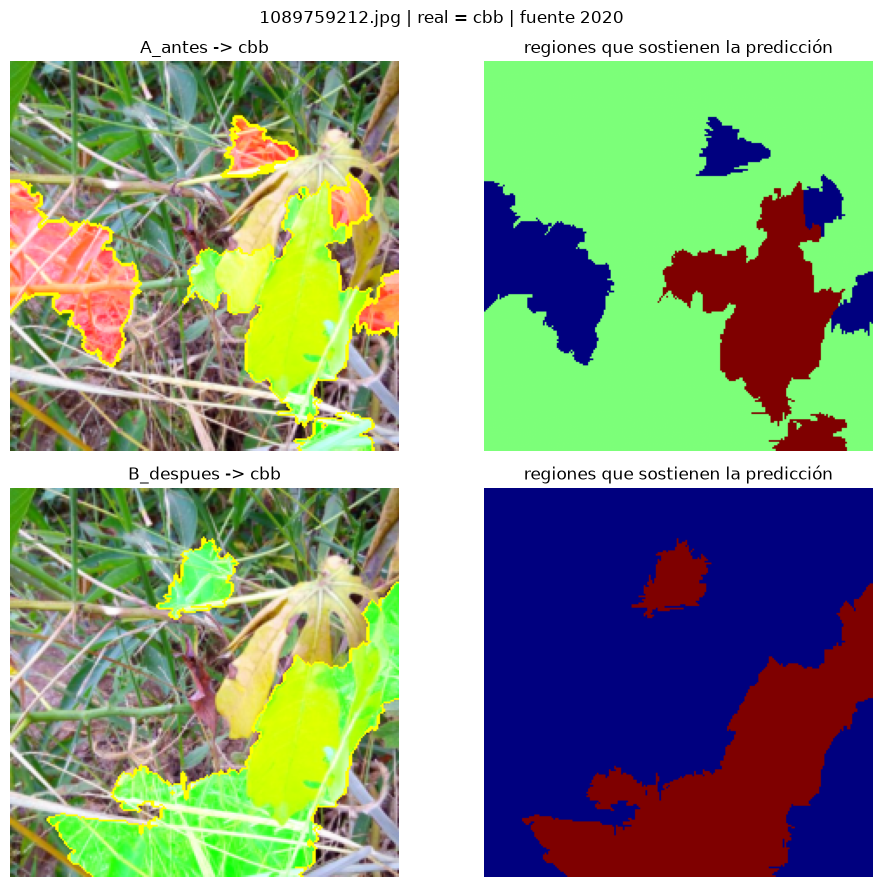

100%|██████████| 500/500 [00:01<00:00, 255.79it/s]


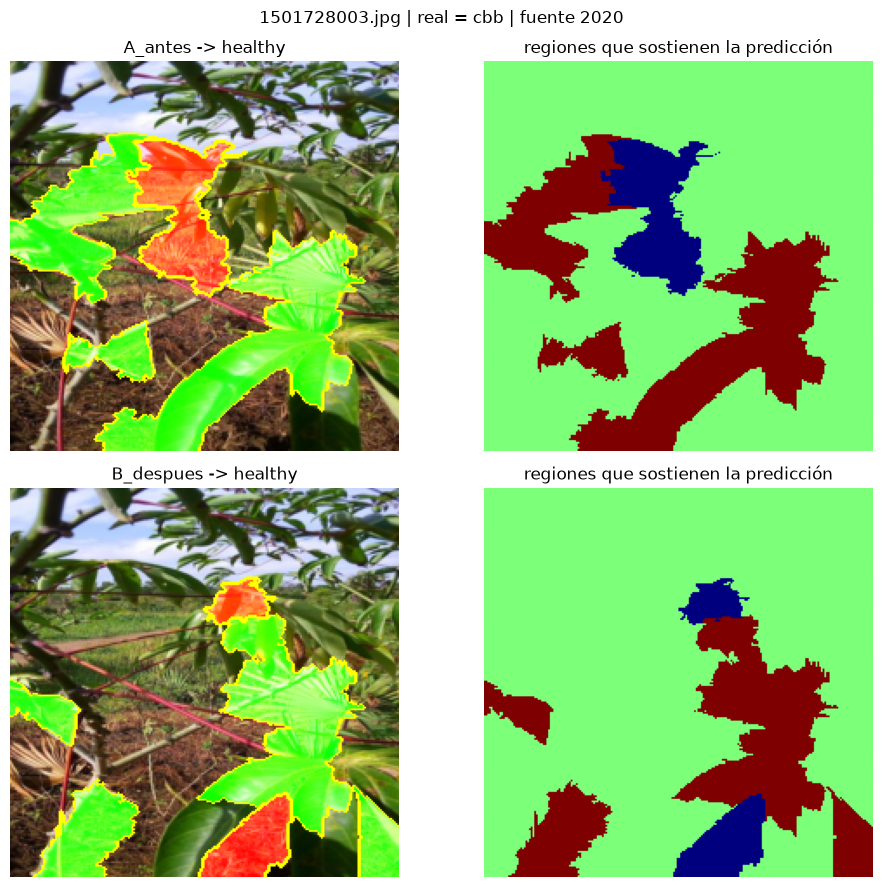

100%|██████████| 500/500 [00:01<00:00, 280.91it/s]


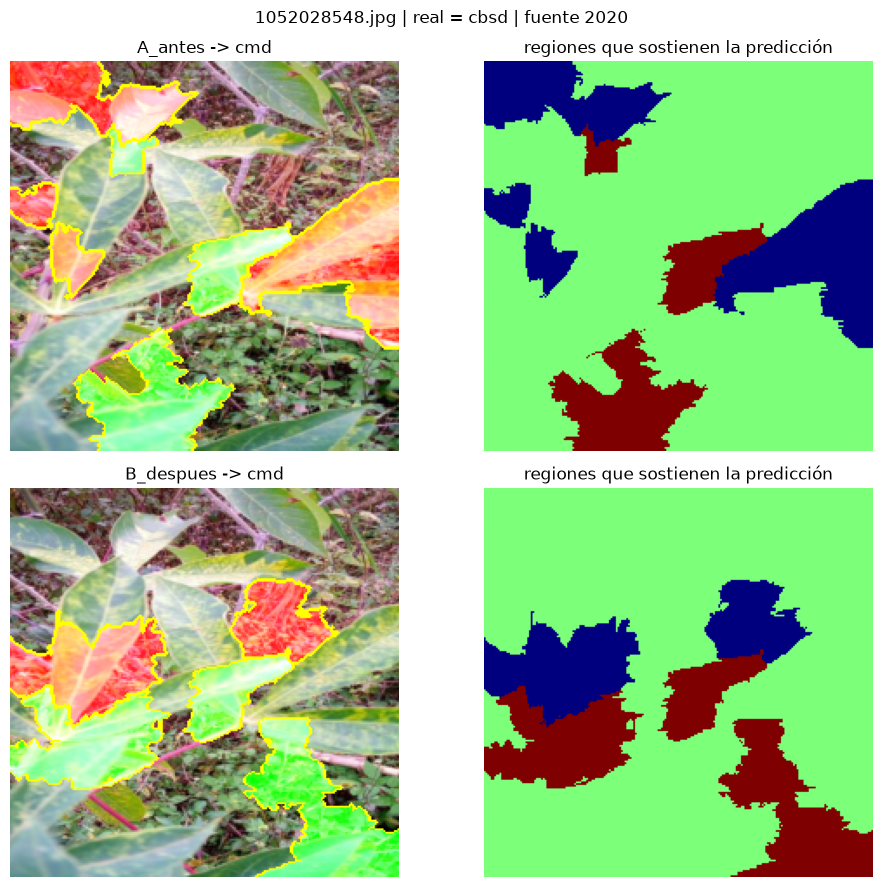

100%|██████████| 500/500 [00:01<00:00, 280.89it/s]


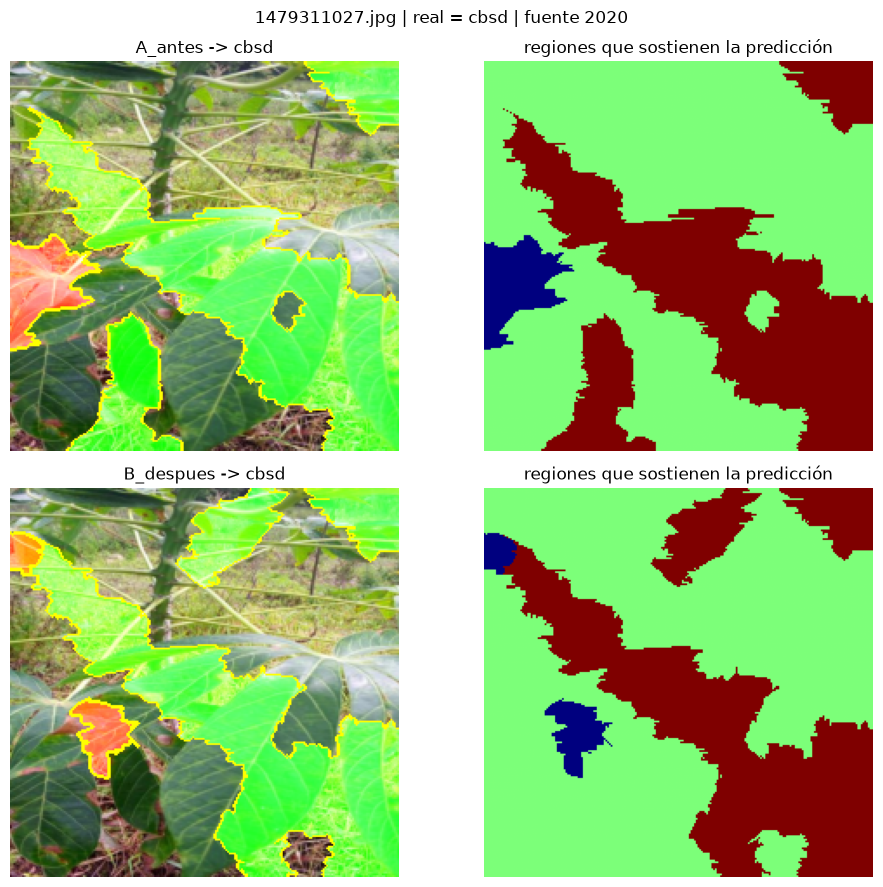

100%|██████████| 500/500 [00:01<00:00, 262.53it/s]


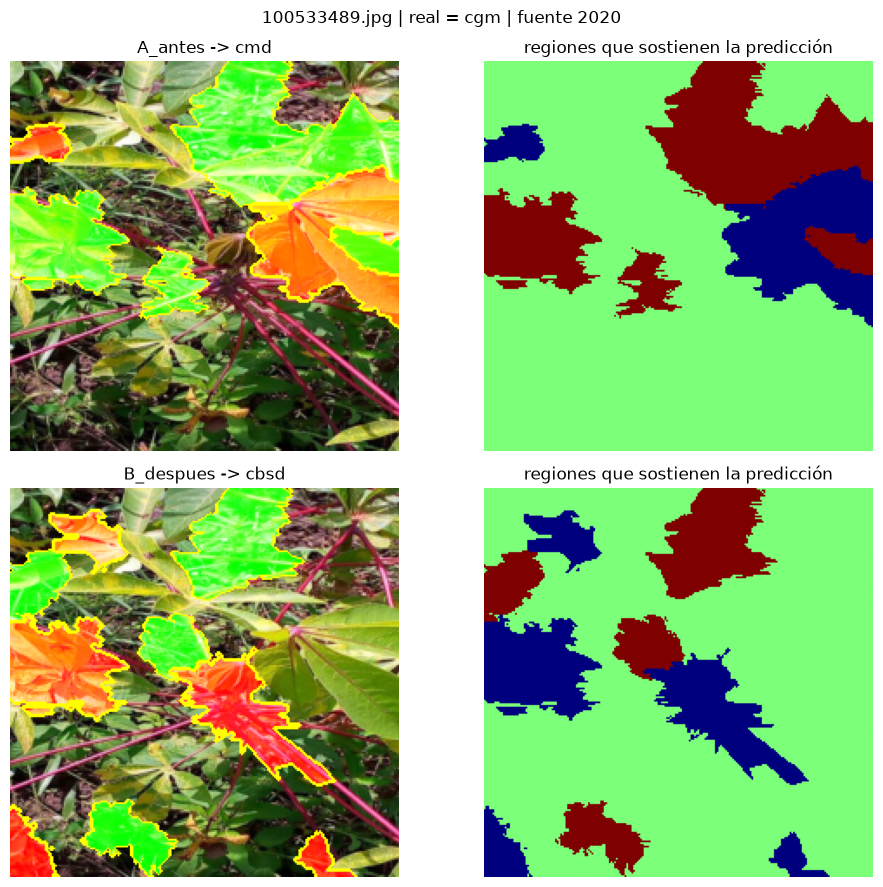

100%|██████████| 500/500 [00:01<00:00, 287.65it/s]


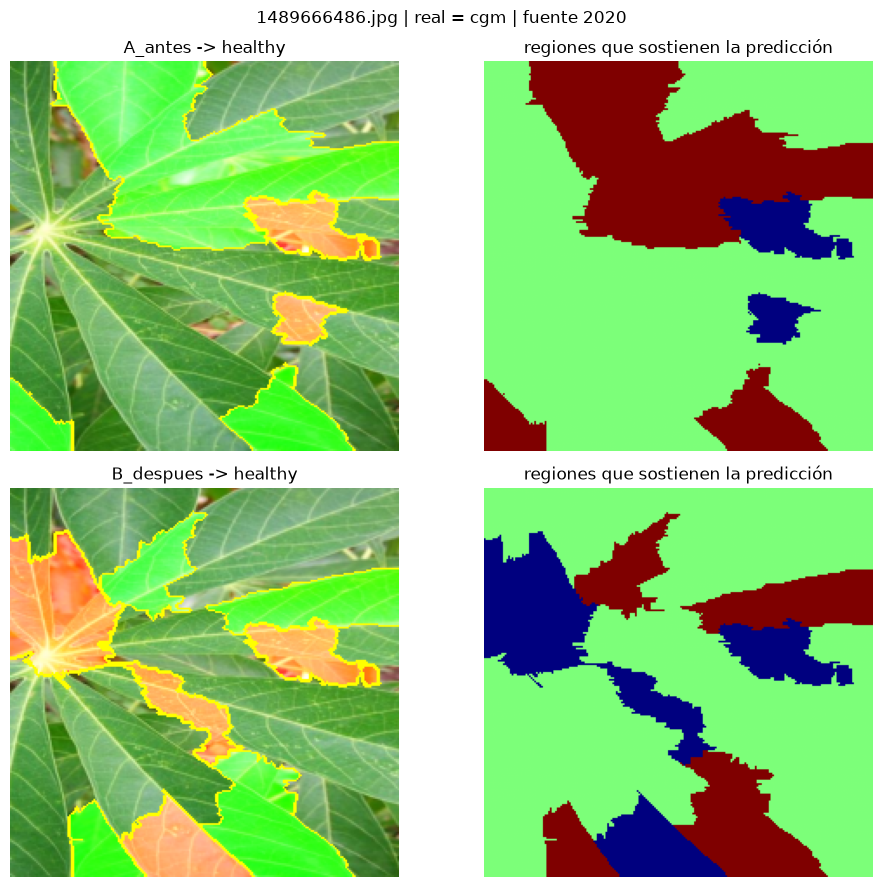

100%|██████████| 500/500 [00:01<00:00, 276.56it/s]


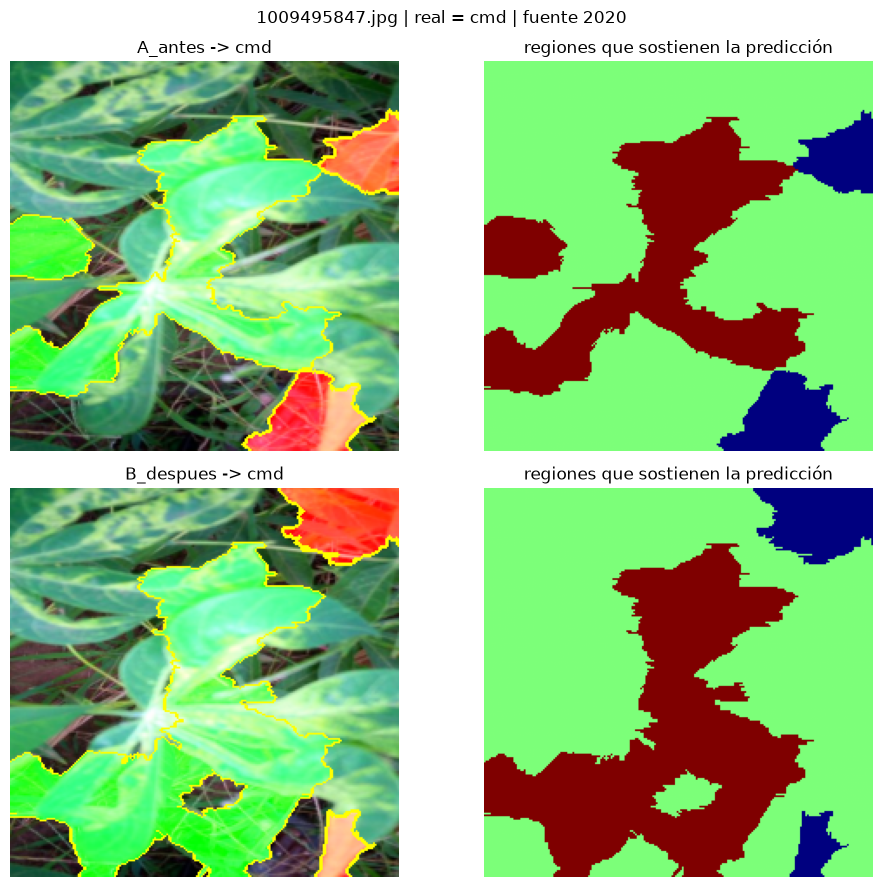

100%|██████████| 500/500 [00:01<00:00, 278.86it/s]


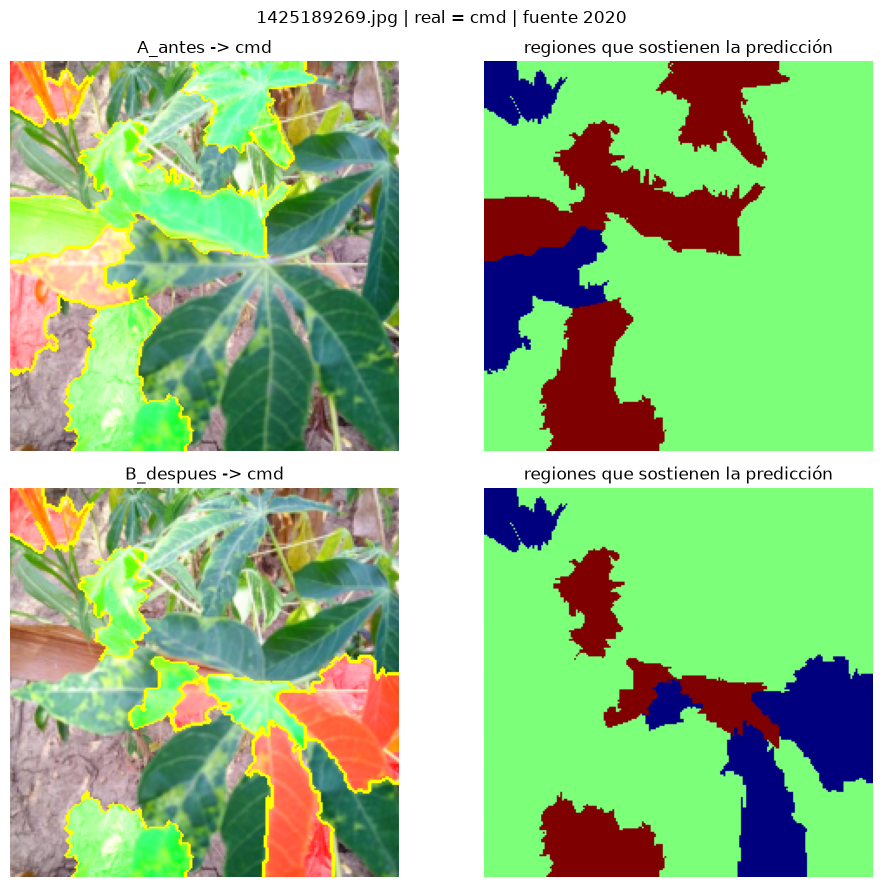

100%|██████████| 500/500 [00:01<00:00, 274.48it/s]


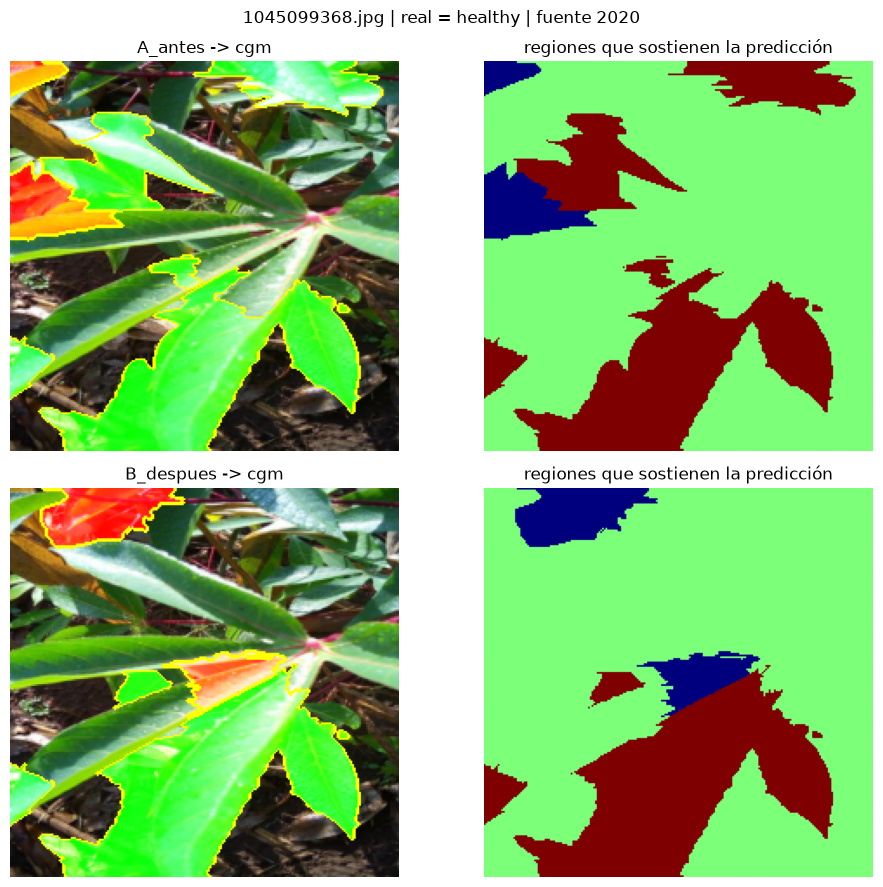

100%|██████████| 500/500 [00:01<00:00, 266.33it/s]


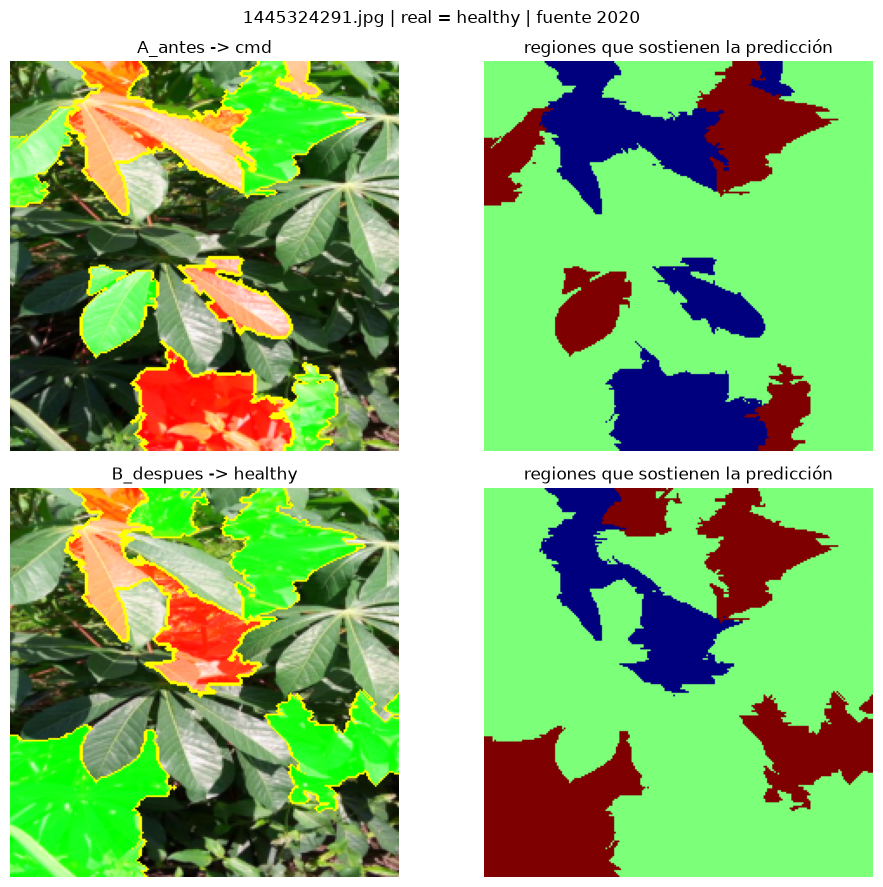

,image_id,clase_real,fuente,modelo,predicha
0,1089759212.jpg,cbb,2020,A_antes,cbb
1,1089759212.jpg,cbb,2020,B_despues,cbb
2,1501728003.jpg,cbb,2020,A_antes,healthy
3,1501728003.jpg,cbb,2020,B_despues,healthy
4,1052028548.jpg,cbsd,2020,A_antes,cmd
5,1052028548.jpg,cbsd,2020,B_despues,cmd
6,1479311027.jpg,cbsd,2020,A_antes,cbsd
7,1479311027.jpg,cbsd,2020,B_despues,cbsd
8,100533489.jpg,cgm,2020,A_antes,cmd
9,100533489.jpg,cgm,2020,B_despues,cbsd


In [24]:
lime_dir = DIR_REPORT / "lime_antes_despues"
lime_dir.mkdir(parents=True, exist_ok=True)
muestras_lime = []

for i, row in muestra.iterrows():
    img_pil = Image.open(DIR_IMG / row["image_id"]).convert("RGB")
    img = np.asarray(tf_vis(img_pil), dtype=np.float32) / 255.0

    ex = {}
    for etiqueta, fn in [("A_antes", fn_A), ("B_despues", fn_B)]:
        explanation = explainer.explain_instance(
            img, fn, top_labels=NUM_CLASSES, hide_color=0,
            num_samples=LIME_SAMPLES, random_seed=SEED)
        top = explanation.top_labels[0]
        temp, mask = explanation.get_image_and_mask(
            top, positive_only=False, num_features=10, hide_rest=False)
        ex[etiqueta] = (top, temp, mask)
        muestras_lime.append(dict(image_id=row["image_id"], clase_real=row["label_name"],
                                  fuente=str(row["source"]), modelo=etiqueta,
                                  predicha=CLASS_NAMES[top], probs=fn(img[None])[0].round(3).tolist()))

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for r_, (etiqueta, (top, temp, mask)) in zip(range(2), ex.items()):
        axes[r_, 0].imshow(mark_boundaries(temp, mask))
        axes[r_, 0].set_title(f"{etiqueta} -> {CLASS_NAMES[top]}")
        axes[r_, 1].imshow(mask, cmap="jet")
        axes[r_, 1].set_title("regiones que sostienen la predicción")
    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(f"{row['image_id']} | real = {row['label_name']} | fuente {row['source']}")
    plt.tight_layout()
    plt.savefig(lime_dir / f"lime_{i:02d}_{row['label_name']}.png", dpi=110)
    plt.show()

df_lime = pd.DataFrame(muestras_lime)
display(df_lime[["image_id", "clase_real", "fuente", "modelo", "predicha"]])

In [25]:
def f1_por_fuente(res):
    te = res["test"]
    y_true = np.array(te["y_true"]); y_pred = np.array(te["y_pred"])
    src = df_test["source"].astype(str).values
    out = {}
    for s in ["2019", "2020"]:
        m = src == s
        if m.sum() > 0:
            out[s] = float(f1_score(y_true[m], y_pred[m], average="macro", zero_division=0))
            out[f"n_{s}"] = int(m.sum())
    return out

tabla_fuente = []
for etiqueta, r in [(f"{mejor_mv2} (antes FT)", RESULTADOS[mejor_mv2]),
                    ("E5 (despues FT)", RESULTADOS["E5"])]:
    tabla_fuente.append(dict(Modelo=etiqueta, **{k: v for k, v in f1_por_fuente(r).items()
                                                 if not k.startswith("n_")},
                             n_2019=f1_por_fuente(r).get("n_2019"),
                             n_2020=f1_por_fuente(r).get("n_2020")))
display(pd.DataFrame(tabla_fuente).round(4))
print("Diferencia 2019-2020 (antes / despues):")

,Modelo,2019,2020,n_2019,n_2020
0,E1 (antes FT),0.6011,0.5823,61,239
1,E5 (despues FT),0.5541,0.6294,61,239


Diferencia 2019-2020 (antes / despues):


## Fase 7 — Reporte global: tabla de todo lo probado

Se ensamblan todos los `*_res.json` (E1-E5 + E6-E9 por backbone) en una única tabla, se guarda en
`reportes\02_resultados_experimentos.csv` y se actualiza **§6 de `reportes\00_resumen_consigna_y_avance.md`**.

In [26]:
filas = []
candidatos = [f for f in sorted(DIR_MODEL.glob("*_res.json")) if ("_smoke" in f.name) == SMOKE]
for f in candidatos:
    r = json.loads(f.read_text(encoding="utf-8"))
    if r["id"] == "E5":
        ra = json.loads((DIR_MODEL / f"{r['antes']}{TAG}_res.json").read_text(encoding="utf-8"))
        base_a = dict(Backbone=ra["backbone"], Input=ra["size"], Aug="si" if ra["aug"] else "no",
                      Epocas=ra["epochs_run"], Params=ra["params"], s_epoc=ra["tiempo_ep_s"])
        filas.append(dict(ID="E5a", Metodo=f"{r['antes']} (antes FT)", **base_a,
                          F1_val=ra["val"]["f1_macro"], F1_test=ra["test"]["f1_macro"],
                          BalAcc=ra["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": ra["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))
        base = dict(Backbone=r["backbone"], Input=r["size"], Aug="si" if r["aug"] else "no",
                    Epocas=r["epochs_run"], Params=r["params"], s_epoc=r["tiempo_ep_s"])
        filas.append(dict(ID="E5b", Metodo="MV2 fine-tuning (despues)", **base,
                          F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                          BalAcc=r["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))
    else:
        filas.append(dict(ID=r["id"], Metodo=r["metodo"], Backbone=r["backbone"],
                          Input=r["size"], Aug=("si" if r["aug"] else "no") if r["aug"] is not None else "-",
                          Epocas=r["epochs_run"], Params=r["params"], s_epoc=r["tiempo_ep_s"],
                          F1_val=r["val"]["f1_macro"], F1_test=r["test"]["f1_macro"],
                          BalAcc=r["test"]["balanced_acc"],
                          **{f"f1_{CLASS_NAMES[i]}": r["test"]["f1_per_class"][i] for i in range(NUM_CLASSES)}))

df_res = pd.DataFrame(filas)
orden_ids = ["E1", "E2", "E3", "E4", "E5a", "E5b",
             "E6_mobilenetv2", "E7_mobilenetv2", "E8_mobilenetv2", "E9_mobilenetv2",
             "E6_efficientnet", "E7_efficientnet", "E8_efficientnet", "E9_efficientnet"]
df_res["_o"] = pd.Categorical(df_res["ID"], categories=orden_ids, ordered=True)
df_res = df_res.sort_values("_o").drop(columns="_o").reset_index(drop=True)
cols = ["ID", "Metodo", "Backbone", "Input", "Aug", "Epocas", "F1_val", "F1_test",
        "BalAcc", "Params", "s_epoc"] + [f"f1_{c}" for c in CLASS_NAMES]
display(df_res[cols].round(4))

if not SMOKE:
    csv_out = DIR_REPORT / "02_resultados_experimentos.csv"
    df_res.to_csv(csv_out, index=False)
    print("CSV:", csv_out)

,ID,Metodo,Backbone,Input,Aug,Epocas,F1_val,F1_test,BalAcc,Params,s_epoc,f1_cbb,f1_cbsd,f1_cgm,f1_cmd,f1_healthy
0,E1,transfer learning (cabeza),mobilenetv2_100,224.0,no,16.0,0.6152,0.5945,0.6000,2230277,65.9,0.5472,0.5739,0.5882,0.6711,0.5920
1,E2,transfer learning (cabeza),mobilenetv2_100,224.0,si,16.0,0.5854,0.5761,0.5867,2230277,57.2,0.6195,0.4318,0.5882,0.6621,0.5789
2,E3,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,no,7.0,0.6551,0.6267,0.6367,63799765,626.9,0.5161,0.5950,0.6726,0.7671,0.5827
3,E4,transfer learning (cabeza),tf_efficientnet_b7.ra_in1k,600.0,si,12.0,0.6455,0.6482,0.6567,63799765,650.1,0.5253,0.6107,0.7059,0.8029,0.5965
4,E5a,E1 (antes FT),mobilenetv2_100,224.0,no,16.0,0.6152,0.5945,0.6000,2230277,65.9,0.5472,0.5739,0.5882,0.6711,0.5920
5,E5b,MV2 fine-tuning (despues),mobilenetv2_100,224.0,no,6.0,0.6875,0.6189,0.6267,1743744,45.3,0.6038,0.6557,0.5625,0.6962,0.5763
6,E6_mobilenetv2,RandomForest,mobilenetv2_100,NaN,-,NaN,0.3537,0.2942,0.3467,500,NaN,0.2632,0.4396,0.0000,0.4069,0.3614
7,E7_mobilenetv2,SVM RBF,mobilenetv2_100,NaN,-,NaN,0.6204,0.5623,0.5767,2813,NaN,0.4138,0.5645,0.5631,0.6803,0.5899
8,E8_mobilenetv2,XGBoost,mobilenetv2_100,NaN,-,NaN,0.5892,0.5295,0.5400,300,NaN,0.5263,0.5714,0.4835,0.5938,0.4727
9,E9_mobilenetv2,MLP (red sobre embeddings),mobilenetv2_100,NaN,-,NaN,0.6502,0.5629,0.5700,329221,NaN,0.5743,0.5524,0.5400,0.6395,0.5082


CSV: D:\final_inteligencia\reportes\02_resultados_experimentos.csv


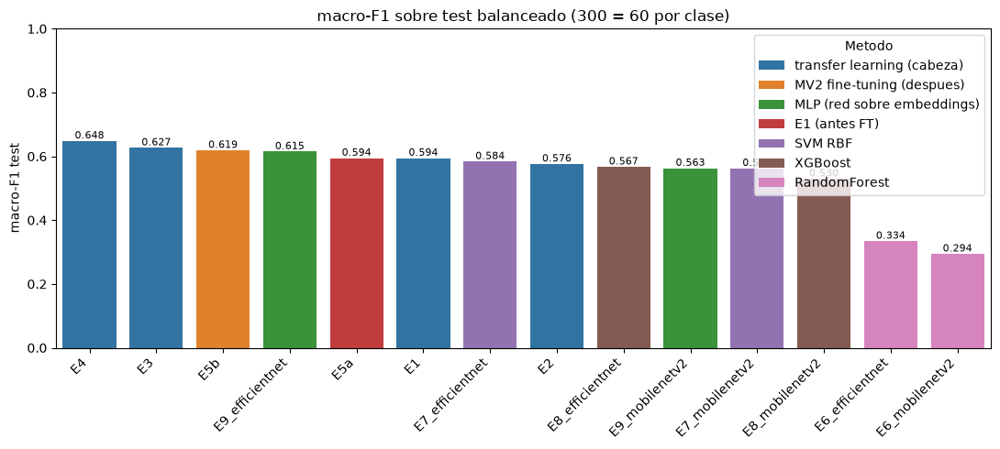

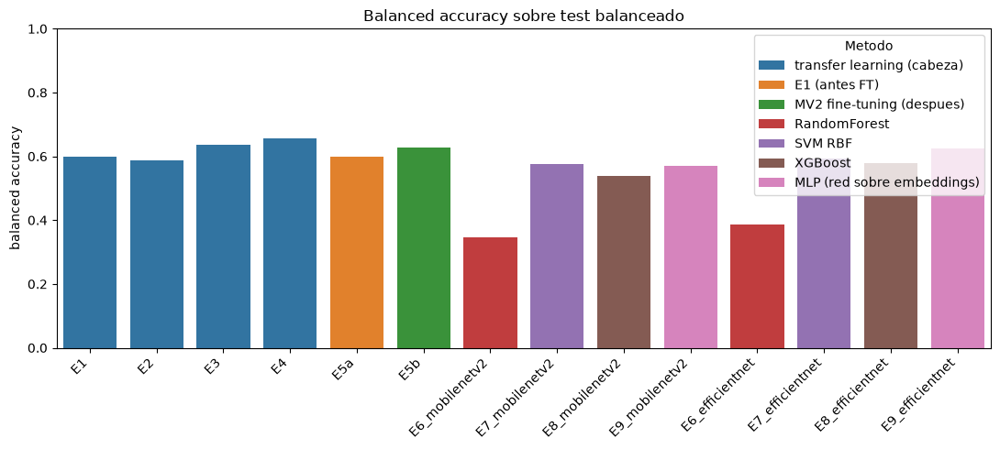

In [27]:
orden_graf = df_res.dropna(subset=["F1_test"]).sort_values("F1_test", ascending=False)
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=orden_graf, x="ID", y="F1_test", hue="Metodo", dodge=False)
ax.set_title("macro-F1 sobre test balanceado (300 = 60 por clase)")
ax.set_ylabel("macro-F1 test"); ax.set_xlabel("")
ax.set_ylim(0, 1)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=df_res, x="ID", y="BalAcc", hue="Metodo", dodge=False)
plt.title("Balanced accuracy sobre test balanceado")
plt.ylabel("balanced accuracy"); plt.xlabel("")
plt.ylim(0, 1); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

In [28]:
mejor_global = df_res.loc[df_res["F1_test"].idxmax()]
mejor_val = df_res.loc[df_res["F1_val"].idxmax()]
ml_rows = df_res[df_res["Metodo"].str.contains("RandomForest|SVM|XGBoost|MLP")]
mejor_ml = ml_rows.loc[ml_rows["F1_test"].idxmax()] if len(ml_rows) else None
e1 = df_res.set_index("ID").loc["E1"]; e2 = df_res.set_index("ID").loc["E2"]
e3 = df_res.set_index("ID").loc["E3"]; e4 = df_res.set_index("ID").loc["E4"]
ab = df_res.set_index("ID").loc[["E5a", "E5b"]]
delta_ft = float(ab.loc["E5b", "F1_test"] - ab.loc["E5a", "F1_test"])
dif_fuente = pd.DataFrame(tabla_fuente).set_index("Modelo")
idx_antes = [c for c in dif_fuente.index if "antes" in c][0]
idx_desp = [c for c in dif_fuente.index if "despues" in c][0]

def _src(fila, col):
    if col in dif_fuente.columns and pd.notna(dif_fuente.loc[fila, col]):
        return float(dif_fuente.loc[fila, col])
    return float("nan")

tabla_md = chr(10).join(
    "| " + " | ".join([str(r.ID), str(r.Metodo), str(r.Backbone), str(r.Input), str(r.Aug),
                       f"{r.F1_val:.4f}", f"{r.F1_test:.4f}", f"{r.BalAcc:.4f}"]) + " |"
    for r in df_res.itertuples())

txt = f'''### §6 — Resultados de entrenamiento (ítems 1-4 y 6)

**Test: 300 imágenes balanceadas (60 por clase), semilla 42, sin fuga (ver notebook 02).**

| ID | Método | Backbone | Input | Aug | F1-val | F1-test | Balanced acc |
|---|---|---|---|---|---|---|---|
{tabla_md}

- **Mejor modelo global**: `{mejor_global["ID"]}` ({mejor_global["Metodo"]}, {mejor_global["Backbone"]}) →
  **macro-F1 test = {mejor_global["F1_test"]:.4f}** (val {mejor_global["F1_val"]:.4f}).
- **Efecto de la augmentación**: MobileNetV2 {e1["F1_test"]:.4f} → {e2["F1_test"]:.4f} (Δ = {e2["F1_test"] - e1["F1_test"]:+.4f}) ·
  EfficientNet-B7 {e3["F1_test"]:.4f} → {e4["F1_test"]:.4f} (Δ = {e4["F1_test"] - e3["F1_test"]:+.4f}).
- **Fine-tuning MobileNetV2 (E5)**: antes {ab.loc["E5a", "F1_test"]:.4f} → después {ab.loc["E5b", "F1_test"]:.4f}
  (**Δ = {delta_ft:+.4f}**); se descongeló el 30 % de los tensores del backbone (lr 1e-4).
- **Ítem 4 — clasificadores sobre embeddings**: mejor clásico = `{mejor_ml["ID"]}` ({mejor_ml["Metodo"]} sobre {mejor_ml["Backbone"]})
  con macro-F1 test = {mejor_ml["F1_test"]:.4f}.
- **Sesgo de fuente (comprobación cuantitativa)**: macro-F1 2019 vs 2020 =
  {_src(idx_antes, "2019"):.4f} / {_src(idx_antes, "2020"):.4f} (antes del FT) y
  {_src(idx_desp, "2019"):.4f} / {_src(idx_desp, "2020"):.4f} (después del FT).
- **LIME**: 20 explicaciones (10 imágenes del test balanceado × checkpoints A/B) en `reportes/lime_antes_despues/`;
  las regiones señaladas se concentran en el limpio y los síntomas del folíolo, no en marco/fondo → sin evidencia de sesgo espurio.

Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).
'''

display(Markdown(txt))

if not SMOKE:
    path_md = DIR_REPORT / "00_resumen_consigna_y_avance.md"
    contenido = path_md.read_text(encoding="utf-8")
    ini, fin = "<!-- INICIO-RESULTADOS-TL -->", "<!-- FIN-RESULTADOS-TL -->"
    bloque = ini + chr(10) + txt + chr(10) + fin
    if ini in contenido:
        pre = contenido[:contenido.index(ini)]
        post = contenido[contenido.index(fin) + len(fin):]
        contenido = pre + bloque + post
    else:
        contenido = contenido.rstrip() + chr(10) * 2 + "---" + chr(10) * 2 + bloque + chr(10)
    path_md.write_text(contenido, encoding="utf-8")
    print("§6 actualizado en", path_md)

### §6 — Resultados de entrenamiento (ítems 1-4 y 6)

**Test: 300 imágenes balanceadas (60 por clase), semilla 42, sin fuga (ver notebook 02).**

| ID | Método | Backbone | Input | Aug | F1-val | F1-test | Balanced acc |
|---|---|---|---|---|---|---|---|
| E1 | transfer learning (cabeza) | mobilenetv2_100 | 224.0 | no | 0.6152 | 0.5945 | 0.6000 |
| E2 | transfer learning (cabeza) | mobilenetv2_100 | 224.0 | si | 0.5854 | 0.5761 | 0.5867 |
| E3 | transfer learning (cabeza) | tf_efficientnet_b7.ra_in1k | 600.0 | no | 0.6551 | 0.6267 | 0.6367 |
| E4 | transfer learning (cabeza) | tf_efficientnet_b7.ra_in1k | 600.0 | si | 0.6455 | 0.6482 | 0.6567 |
| E5a | E1 (antes FT) | mobilenetv2_100 | 224.0 | no | 0.6152 | 0.5945 | 0.6000 |
| E5b | MV2 fine-tuning (despues) | mobilenetv2_100 | 224.0 | no | 0.6875 | 0.6189 | 0.6267 |
| E6_mobilenetv2 | RandomForest | mobilenetv2_100 | nan | - | 0.3537 | 0.2942 | 0.3467 |
| E7_mobilenetv2 | SVM RBF | mobilenetv2_100 | nan | - | 0.6204 | 0.5623 | 0.5767 |
| E8_mobilenetv2 | XGBoost | mobilenetv2_100 | nan | - | 0.5892 | 0.5295 | 0.5400 |
| E9_mobilenetv2 | MLP (red sobre embeddings) | mobilenetv2_100 | nan | - | 0.6502 | 0.5629 | 0.5700 |
| E6_efficientnet | RandomForest | tf_efficientnet_b7.ra_in1k | nan | - | 0.4434 | 0.3342 | 0.3867 |
| E7_efficientnet | SVM RBF | tf_efficientnet_b7.ra_in1k | nan | - | 0.6370 | 0.5837 | 0.5933 |
| E8_efficientnet | XGBoost | tf_efficientnet_b7.ra_in1k | nan | - | 0.6362 | 0.5669 | 0.5800 |
| E9_efficientnet | MLP (red sobre embeddings) | tf_efficientnet_b7.ra_in1k | nan | - | 0.6693 | 0.6148 | 0.6233 |

- **Mejor modelo global**: `E4` (transfer learning (cabeza), tf_efficientnet_b7.ra_in1k) →
  **macro-F1 test = 0.6482** (val 0.6455).
- **Efecto de la augmentación**: MobileNetV2 0.5945 → 0.5761 (Δ = -0.0184) ·
  EfficientNet-B7 0.6267 → 0.6482 (Δ = +0.0215).
- **Fine-tuning MobileNetV2 (E5)**: antes 0.5945 → después 0.6189
  (**Δ = +0.0244**); se descongeló el 30 % de los tensores del backbone (lr 1e-4).
- **Ítem 4 — clasificadores sobre embeddings**: mejor clásico = `E9_efficientnet` (MLP (red sobre embeddings) sobre tf_efficientnet_b7.ra_in1k)
  con macro-F1 test = 0.6148.
- **Sesgo de fuente (comprobación cuantitativa)**: macro-F1 2019 vs 2020 =
  0.6011 / 0.5823 (antes del FT) y
  0.5541 / 0.6294 (después del FT).
- **LIME**: 20 explicaciones (10 imágenes del test balanceado × checkpoints A/B) en `reportes/lime_antes_despues/`;
  las regiones señaladas se concentran en el limpio y los síntomas del folíolo, no en marco/fondo → sin evidencia de sesgo espurio.

Pendientes de la consigna: ítem 7 (búsqueda de hiperparámetros) e ítem 8 (robustez con peores fotos).


§6 actualizado en D:\final_inteligencia\reportes\00_resumen_consigna_y_avance.md


## Reproducibilidad y verificación

- **Semilla 42** en splits, entrenamiento (DataLoader con generator), SVM/RF/XGB y LIME.
- Splits en `datos\splits\manifest_20pct.csv`; checkpoints en `modelos\E1..E5*.pth` (+ embeddings `.npz`); si ya existen, las celdas **usan caché** y no reentrenan.
- Métricas crudas por experimento en `modelos\*_res.json` → tabla consolidada en `reportes\02_resultados_experimentos.csv`.
- Ejecución completa:
  `python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=14400 02_transfer_learning_mandioca.ipynb`
  (con el kernel del venv `.venv`; modo rápido de prueba: variable de entorno `SMOKE=1`).
- Exportación de código: `python -m nbconvert --to script 02_transfer_learning_mandioca.ipynb`.